In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import sys
sys.path.append("..")
from dpa.dpa_fit import DPA

In [2]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
# First, transpose to (time, lat, lon) if needed
def data_to_torch(ds):
    temp_data = ds['Temperature']
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [4]:
# load my temperature data
# Load your NetCDF file
ds_train = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_le.nc")
ds_test = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/ds_eth_test.nc")
ds_train


<xarray.Dataset> Size: 5GB
Dimensions:         (lat: 32, lon: 32, time: 301200, predictor_mode: 1001)
Coordinates:
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * time            (time) object 2MB 1850-01-01 00:00:00 ... 2100-12-01 00:0...
  * predictor_mode  (predictor_mode) int64 8kB 0 1 2 3 4 ... 997 998 999 1000
Data variables:
    Temperature     (lat, lon, time) float64 2GB ...
    Predictors      (predictor_mode, time) float64 2GB ...

In [5]:
ds_test

<xarray.Dataset> Size: 586MB
Dimensions:         (lat: 32, lon: 32, time: 36144, predictor_mode: 1001)
Coordinates:
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * time            (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00...
  * predictor_mode  (predictor_mode) int64 8kB 0 1 2 3 4 ... 997 998 999 1000
Data variables:
    Temperature     (lat, lon, time) float64 296MB ...
    Predictors      (predictor_mode, time) float64 289MB ...

In [6]:
x_tr = data_to_torch(ds_train)
x_te = data_to_torch(ds_test)

torch.Size([301200, 1024])
torch.Size([36144, 1024])


In [7]:
dpa = DPA(data_dim=1024, latent_dims=[10,9,8,7,6,5,4,3,2,1,0], num_layer=4, hidden_dim=500, device=device)

Running on CPU.



In [8]:
# when using GPU
# Path to the saved model file
model_path = "saved_modelsmodel_20.pt"

# Load the state dict from the .pt file
state_dict = torch.load(model_path)

# Load the state dict into the internal DPA model
dpa.model.load_state_dict(state_dict)

<All keys matched successfully>

In [8]:
# when using cpu
import torch

# Path to the saved model file
model_path = "saved_modelsmodel_20.pt"  # ← fixed missing slash too

# Load the state dict on CPU
state_dict = torch.load(model_path, map_location=torch.device('cpu'))

# Load the state dict into the internal DPA model
dpa.model.load_state_dict(state_dict)


<All keys matched successfully>

In [8]:
#dpa.train(x_tr, x_te, batch_size=500, num_epochs=20, save_model_every=5, print_every_nepoch=1, save_dir="./saved_models", save_loss=True)

Start training with 603 batches each of size 500.

[Epoch 1] 13.9588, 13.9247, 13.9206, 14.0163, 14.4296, 15.3883, 17.4688, 18.4473, 21.1283, 24.9322, 43.8952
 pred 	23.5316, 24.2231, 24.8740, 25.4088, 26.6815, 28.5547, 32.2556, 33.9496, 38.1032, 43.7576, 63.7569
 var 	19.1456, 20.5968, 21.9068, 22.7851, 24.5039, 26.3328, 29.5736, 31.0046, 33.9499, 37.6508, 39.7233
(test)	10.1263, 10.1459, 10.1793, 10.6290, 11.3002, 12.4441, 14.4169, 15.6525, 19.1774, 23.4718, 41.5400
 pred 	20.1253, 20.5430, 20.9733, 21.9337, 23.4389, 25.8707, 30.0383, 32.3577, 38.8904, 46.4224, 65.7686
 var 	19.9980, 20.7942, 21.5880, 22.6095, 24.2773, 26.8532, 31.2429, 33.4105, 39.4260, 45.9012, 48.4573

[Epoch 2] 9.7270, 9.8360, 9.9662, 10.5118, 11.1891, 12.2682, 14.1461, 15.5962, 19.2718, 23.5011, 41.8060
 pred 	19.3781, 19.7958, 20.2779, 21.3823, 22.8506, 25.1487, 29.0948, 31.8909, 39.3783, 47.7329, 67.6143
 var 	19.3022, 19.9194, 20.6234, 21.7410, 23.3230, 25.7609, 29.8975, 32.5894, 40.2131, 48.4636, 51.6166
(te

[Epoch 1] 1.2245, 1.2285, 1.3391, 1.3720
 pred 	1.5449, 1.5591, 1.7082, 1.7651
 var 	0.6409, 0.6611, 0.7382, 0.7863
(test)	0.7091, 0.7102, 1.0699, 1.2200
 pred 	1.0512, 1.0622, 1.5509, 1.7552
 var 	0.6841, 0.7038, 0.9619, 1.0705

[Epoch 100] 0.0594, 0.1111, 0.3956, 1.0967
 pred 	0.1446, 0.2681, 0.8570, 2.0987
 var 	0.1704, 0.3140, 0.9227, 2.0040
(test)	0.0588, 0.1131, 0.3968, 1.0912
 pred 	0.1441, 0.2729, 0.8524, 2.0949
 var 	0.1706, 0.3197, 0.9112, 2.0073

[Epoch 200] 0.0436, 0.0803, 0.3529, 1.0959
 pred 	0.1114, 0.1884, 0.7508, 2.1283
 var 	0.1356, 0.2162, 0.7957, 2.0648
(test)	0.0419, 0.0799, 0.3479, 1.0943
 pred 	0.1096, 0.1889, 0.7517, 2.1342
 var 	0.1355, 0.2180, 0.8077, 2.0798

[Epoch 300] 0.0376, 0.0720, 0.3424, 1.0827
 pred 	0.0961, 0.1649, 0.7205, 2.1460
 var 	0.1171, 0.1857, 0.7562, 2.1267
(test)	0.0438, 0.0752, 0.3443, 1.0940
 pred 	0.1031, 0.1684, 0.7236, 2.1522
 var 	0.1186, 0.1865, 0.7586, 2.1164

[Epoch 400] 0.0330, 0.0678, 0.3291, 1.0842
 pred 	0.0849, 0.1540, 0.6941, 

In [11]:
x_te.shape

torch.Size([36144, 1024])

In [9]:
x_re_1 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()

In [10]:
x_re_1 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()
x_re_2 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()
x_re_3 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()
x_re_4 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()
x_re_5 = dpa.reconstruct(x_te, gen_sample_size=1).cpu()

x_re_1.shape

torch.Size([36144, 1024])

In [11]:
import torch
import xarray as xr

def torch_to_dataarray(x_tensor, coords_ds, lat_dim=32, lon_dim=32, name="variable"):
    """
    Convert a flattened 2D torch tensor to a 3D xarray.DataArray (lat, lon, time).

    Parameters:
    ----------
    x_tensor : torch.Tensor
        A 2D tensor of shape (time_steps, lat_dim * lon_dim), or a 1D tensor to be reshaped.
    lat_dim : int
        Number of latitude points.
    lon_dim : int
        Number of longitude points.
    coords_ds : xarray.Dataset
        Dataset containing 'lat', 'lon', and 'time' coordinates to assign.
    name : str, optional
        Name of the variable in the DataArray.

    Returns:
    -------
    xarray.DataArray
        The reshaped and labeled data as an xarray.DataArray.
    """
    # Step 1: Convert to NumPy
    data_np = x_tensor.detach().cpu().numpy()

    # Step 2: Determine time_steps and reshape
    time_steps = data_np.shape[0]
    data_np = data_np.reshape(time_steps, lat_dim, lon_dim)

    # Step 3: Transpose to (lat, lon, time)
    data_np = data_np.transpose(1, 2, 0)

    # Step 4: Create the DataArray
    da = xr.DataArray(
        data_np,
        dims=("lat", "lon", "time"),
        coords={
            "lat": coords_ds.lat,
            "lon": coords_ds.lon,
            "time": coords_ds.time
        },
        name=name
    )

    return da


In [13]:
# Assuming:
# - x_re is a tensor of shape (time_steps, lat_dim * lon_dim)
# - ds_test is the reference dataset containing lat/lon/time

reconstructed_da_1 = torch_to_dataarray(x_re_1, coords_ds=ds_test, name="Temperature")
reconstructed_da_2 = torch_to_dataarray(x_re_2, coords_ds=ds_test, name="Temperature")
reconstructed_da_3 = torch_to_dataarray(x_re_3, coords_ds=ds_test, name="Temperature")
reconstructed_da_4 = torch_to_dataarray(x_re_4, coords_ds=ds_test, name="Temperature")
reconstructed_da_5 = torch_to_dataarray(x_re_5, coords_ds=ds_test, name="Temperature")



In [16]:
# Assume you still know lat_dim and lon_dim
# (You saved these when you flattened earlier!)
lat_dim, lon_dim = 32, 32
time_steps = 36144
# Step 1: (optional if needed) Move from torch to numpy
data_np_reverted = x_re.numpy()

# Step 2: Reshape to (time_steps, lat_dim, lon_dim)
data_np_reverted = data_np_reverted.reshape(time_steps, lat_dim, lon_dim)

# Step 3: Transpose to (lat_dim, lon_dim, time_steps)
data_np_reverted = data_np_reverted.transpose(1, 2, 0)  # Now (lat, lon, time)

print(data_np_reverted.shape) 

# Create the DataArray
reconstructed_da = xr.DataArray(
    data_np_reverted,
    dims=("lat", "lon", "time"),
    coords={
        "lat": ds_test.lat,
        "lon": ds_test.lon,
        "time": ds_test.time
    },
    name="Temperature"  # You can name the variable
)

reconstructed_da

(32, 32, 36144)


<xarray.DataArray 'Temperature' (lat: 32, lon: 32, time: 36144)> Size: 148MB
array([[[-0.08056071,  0.5573886 ,  0.52256966, ...,  1.9201496 ,
          2.3604665 ,  2.0576437 ],
        [-0.5980703 ,  0.55942696,  0.29156202, ...,  2.0695887 ,
          2.0647905 ,  2.3460448 ],
        [-0.27659044,  0.4901035 ,  0.2529811 , ...,  2.5434117 ,
          2.1348126 ,  2.7294927 ],
        ...,
        [ 2.093732  , -0.53213745,  0.57975006, ...,  1.4006836 ,
          3.7567062 ,  3.2837844 ],
        [ 2.182991  , -0.3444587 ,  1.0152732 , ...,  1.3757985 ,
          3.9002266 ,  2.951169  ],
        [ 1.9748486 , -0.2527487 ,  0.92914444, ...,  1.3744526 ,
          3.3850188 ,  3.3155773 ]],

       [[-0.12704198,  0.50564325,  0.8752091 , ...,  2.0314598 ,
          1.8166337 ,  2.70203   ],
        [-0.87712866,  0.4982701 ,  0.67719734, ...,  2.5203116 ,
          2.277089  ,  1.8492638 ],
        [-0.8137337 ,  0.45536372,  0.8283187 , ...,  2.8161497 ,
          1.9021894 ,  2.897656  ],
...
        [ 6.682767  ,  6.1547146 , -2.291201  , ...,  4.5474577 ,
          1.8074179 ,  4.862871  ],
        [ 7.361116  ,  5.5763865 , -1.4458554 , ...,  4.3962717 ,
          2.263114  ,  4.9524302 ],
        [ 7.6811547 ,  6.342538  , -1.8609171 , ...,  4.867118  ,
          2.8598638 ,  5.626646  ]],

       [[-0.6541205 ,  0.55088556,  0.06848712, ..., -1.4615009 ,
         -1.6873473 ,  1.4628754 ],
        [-1.169048  ,  0.16015404, -0.04523081, ..., -1.649684  ,
         -1.3688778 ,  1.0361629 ],
        [-0.9958082 ,  0.47785336,  0.03999744, ..., -1.4684838 ,
         -0.75966203,  1.1281335 ],
        ...,
        [ 7.3318253 ,  5.789975  , -1.1390141 , ...,  4.5725384 ,
          2.2029092 ,  5.336804  ],
        [ 7.8916693 ,  6.2289796 , -1.9436624 , ...,  5.125376  ,
          1.9031942 ,  5.553703  ],
        [ 8.173058  ,  5.7980123 , -1.234169  , ...,  4.560428  ,
          2.17537   ,  5.4222193 ]]], shape=(32, 32, 36144), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00:00:00

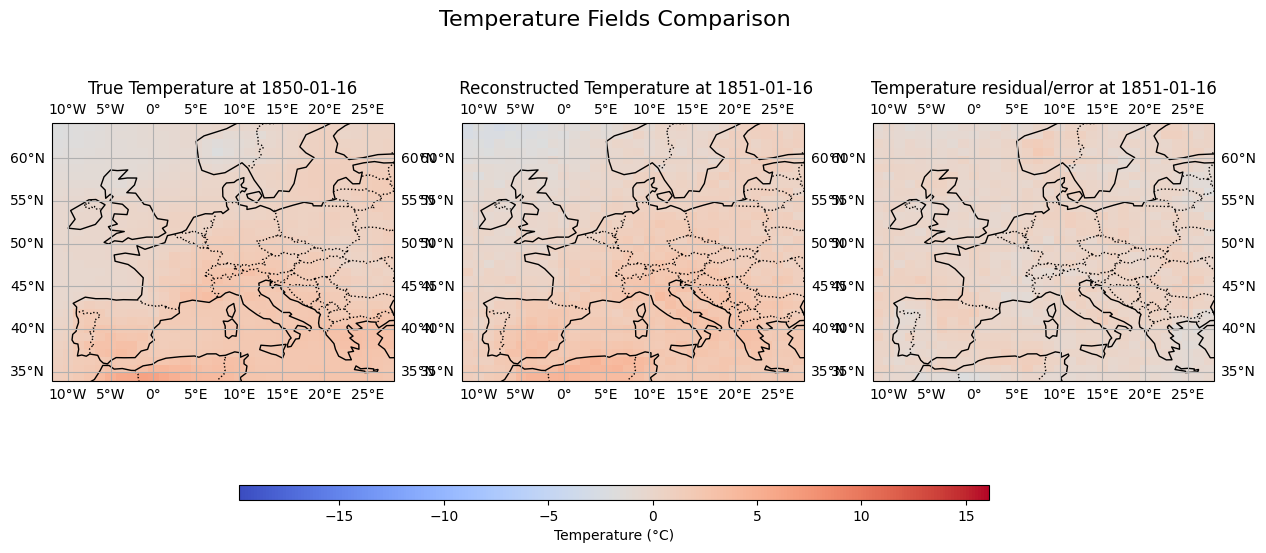

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[ 0.02012706,  0.51995242,  0.36368382, ...,  0.64705133,
         0.56891847,  0.41172445],
       [-0.41864586, -0.44340324,  0.24845767, ...,  0.88952732,
         0.48092794,  0.64109445],
       [-0.18926752,  0.2972821 ,  0.72947037, ...,  0.98633838,
         0.65580428,  0.14359713],
       ...,
       [-0.00955749,  0.19443536,  0.68611813, ..., -0.5264554 ,
        -0.21508348, -0.41334581],
       [ 0.69813633,  0.38584328,  0.6501646 , ..., -0.60575438,
         0.22800958, -0.29517347],
       [ 0.9238925 ,  0.17176306,  0.69945812, ..., -0.09191573,
         0.05644792, -0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [48]:
# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Example: Load data (you should already have your `reconstructed_da`)
# reconstructed_da = xr.open_dataset('your_file.nc')['Temperature']

# Prepare figure with 2 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()


# Set common color limits across both plots
vmin = reconstructed_da.min().item()
vmax = reconstructed_da.max().item()

# Plot on first panel
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important! No individual colorbars
)
axs[0].set_title(f"True Temperature at {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

#####################################################################
# Plot on second panel
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[1].set_title(f" Reconstructed Temperature at {str(time2.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

#####################################################################
# Plot on third panel
p3 = (reconstruction_to_plot - test_truth_to_plot).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[2].set_title(f"Temperature residual/error at {str(time2.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# ===========================
# Here's the important fix:
# Create a new axes for the colorbar
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.03])  
# [left, bottom, width, height] in figure coordinates (0 to 1)

cbar = fig.colorbar(p2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature (°C)')
# ===========================

# Add an overall figure title
fig.suptitle('Temperature Fields Comparison', fontsize=16)

#plt.tight_layout()
plt.show()

test_truth_to_plot - reconstruction_to_plot

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_temperature_panel(ax, dataarray, vmax_shared, sample_nr=None, title=""):
    """
    Plot a single temperature panel on a given axis with Cartopy.

    Parameters:
    ----------
    ax : matplotlib.axes._subplots.AxesSubplot
        Axis on which to plot.
    dataarray : xarray.DataArray
        The temperature data to plot.
    title : str
        Title for the subplot.
    vmax_shared : float
        Symmetric max value for colormap scaling (vmin = -vmax).
    """
    levels = np.linspace(-5, 5, 11)

    p = dataarray.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=-vmax_shared,
        vmax=vmax_shared,
        levels=levels,
        add_colorbar=False
    )
    ax.set_title(title)
    ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    #ax.gridlines(draw_labels=False)
    if sample_nr is not None:
        ax.text(
            x=0, y=0.5,                # left edge, center vertically
            s=sample_nr,          # your annotation text
            transform=ax.transAxes,   # interpret x/y in axis coordinates (0–1)
            rotation=90,              # rotate to align with y-axis
            va='center', ha='right',  # vertical/horizontal alignment
            fontsize=12
        )
    return p


In [17]:
ds_test

<xarray.Dataset> Size: 586MB
Dimensions:         (lat: 32, lon: 32, time: 36144, predictor_mode: 1001)
Coordinates:
  * lat             (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon             (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
  * time            (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00...
  * predictor_mode  (predictor_mode) int64 8kB 0 1 2 3 4 ... 997 998 999 1000
Data variables:
    Temperature     (lat, lon, time) float64 296MB ...
    Predictors      (predictor_mode, time) float64 289MB ...

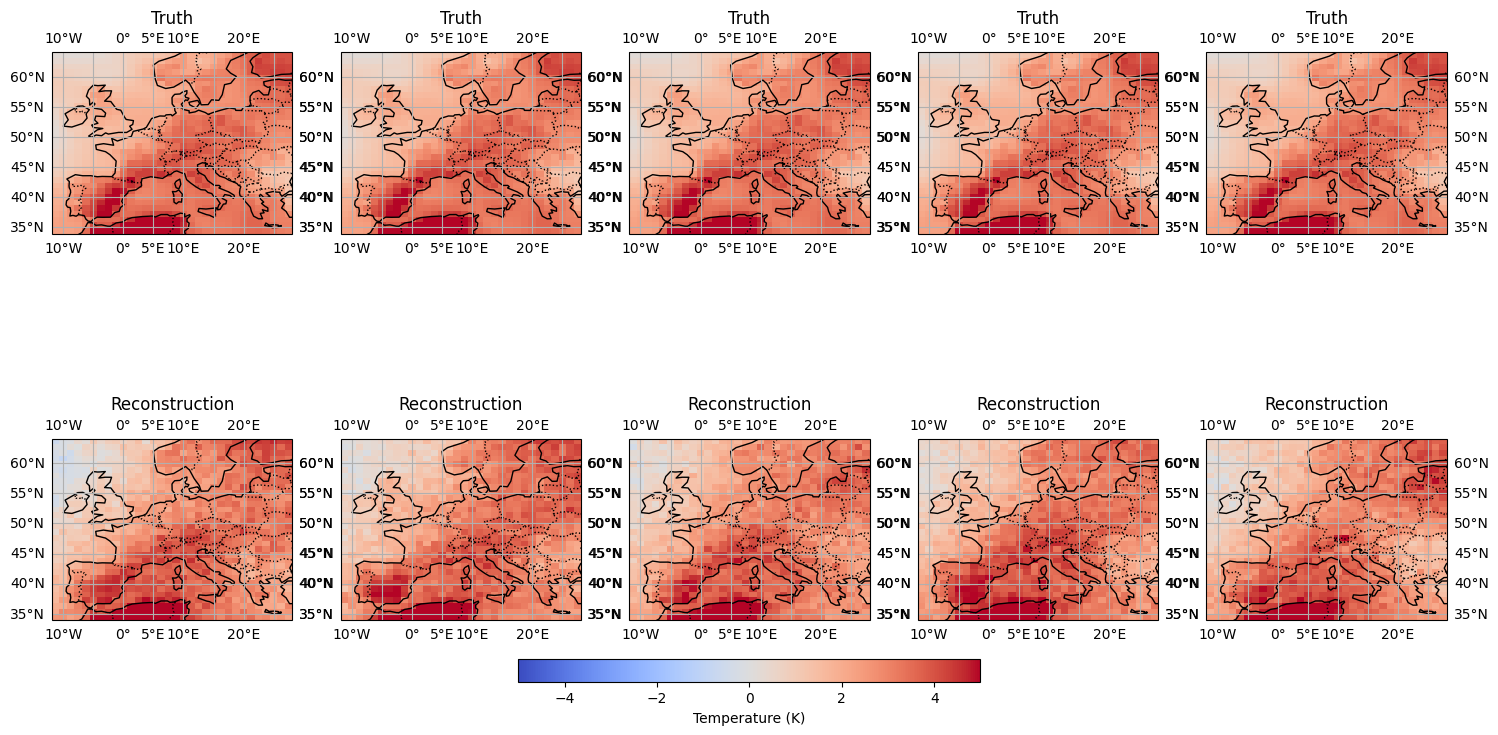

In [21]:
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
list_of_dataarrays_re = [reconstructed_da_1, reconstructed_da_2, reconstructed_da_3, reconstructed_da_4, reconstructed_da_5]
timestep=1000
for i, (ax, da) in enumerate(zip(axs, list_of_dataarrays_re)):
    #title = f"True Temperature at timestep {str(da.isel(time=t).time.values)[:10]}"
    plot_temperature_panel(ax, ds_test.Temperature.isel(time=timestep), title = "Truth", vmax_shared=5)
    plot_temperature_panel(axs[i+5], da.isel(time=timestep), title = "Reconstruction", vmax_shared=5)


# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

#plt.tight_layout()
plt.show()

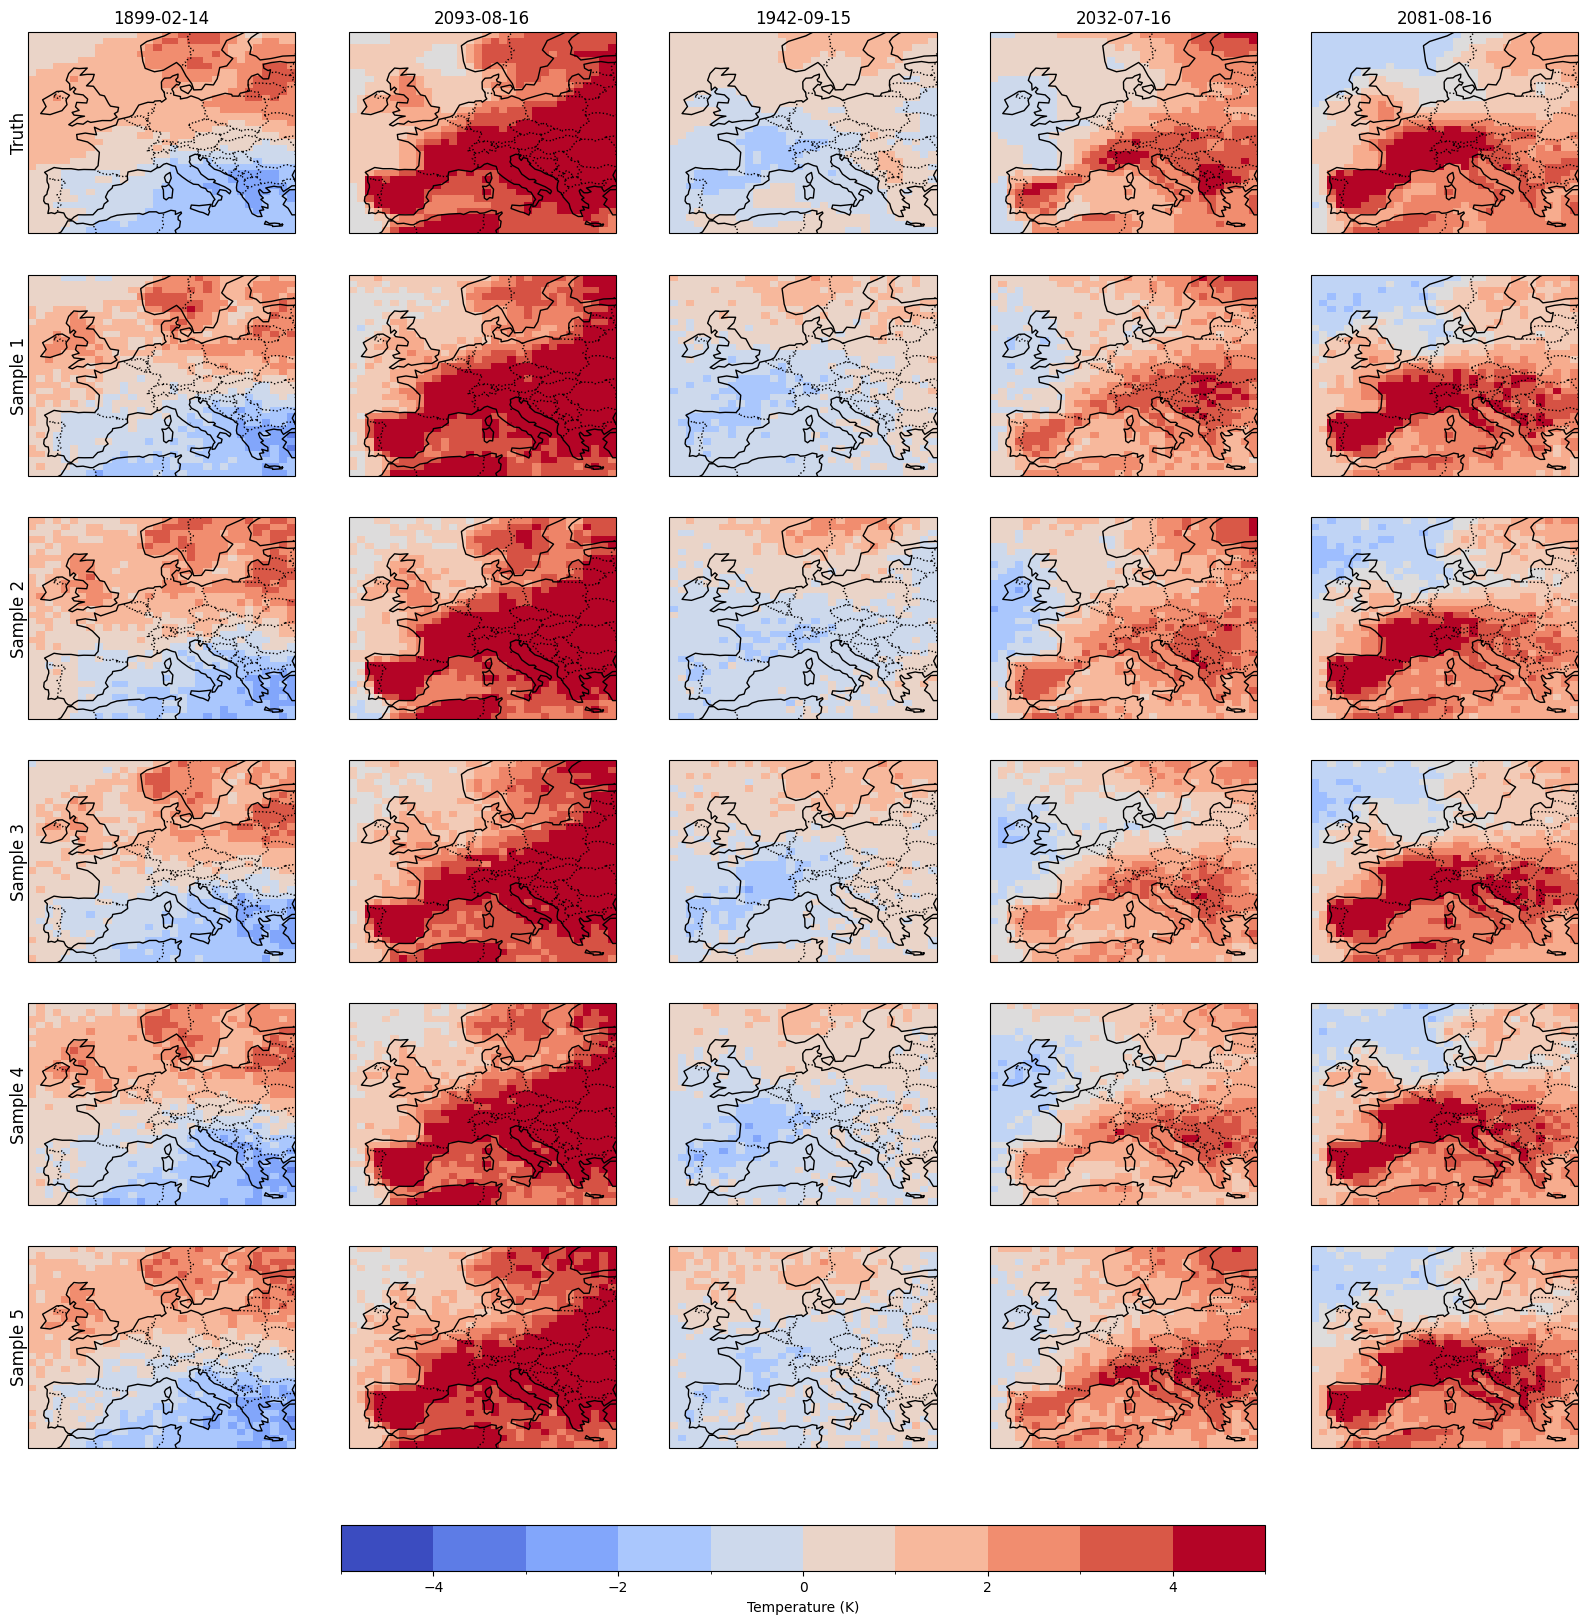

In [16]:
fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
list_of_dataarrays_re = [reconstructed_da_1, reconstructed_da_2, reconstructed_da_3, reconstructed_da_4, reconstructed_da_5]
timesteps=[300,2000,2100,4700,5000]
for i, (ax, t) in enumerate(zip(axs, timesteps)):
    title = f"{str(ds_test.isel(time=t).time.values)[:10]}"
    if i ==0:
        plot_temperature_panel(ax, ds_test.Temperature.isel(time=t), title = title, vmax_shared=5, sample_nr = "Truth")
        plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5, sample_nr = "Sample 1")
        plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5, sample_nr = "Sample 2")
        plot_temperature_panel(axs[i+15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5, sample_nr = "Sample 3")
        plot_temperature_panel(axs[i+20], list_of_dataarrays_re[3].isel(time=t), vmax_shared=5, sample_nr = "Sample 4")
        plot_temperature_panel(axs[i+25], list_of_dataarrays_re[4].isel(time=t), vmax_shared=5, sample_nr = "Sample 5")
    else:
        plot_temperature_panel(ax, ds_test.Temperature.isel(time=t), title = title, vmax_shared=5)
        plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+20], list_of_dataarrays_re[3].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+25], list_of_dataarrays_re[4].isel(time=t), vmax_shared=5)
        




# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

#plt.tight_layout()
plt.savefig("dpa_samples.pdf", format='pdf')
plt.show()

In [ ]:
# Temperature-Verteilung in einer grid-cell ?

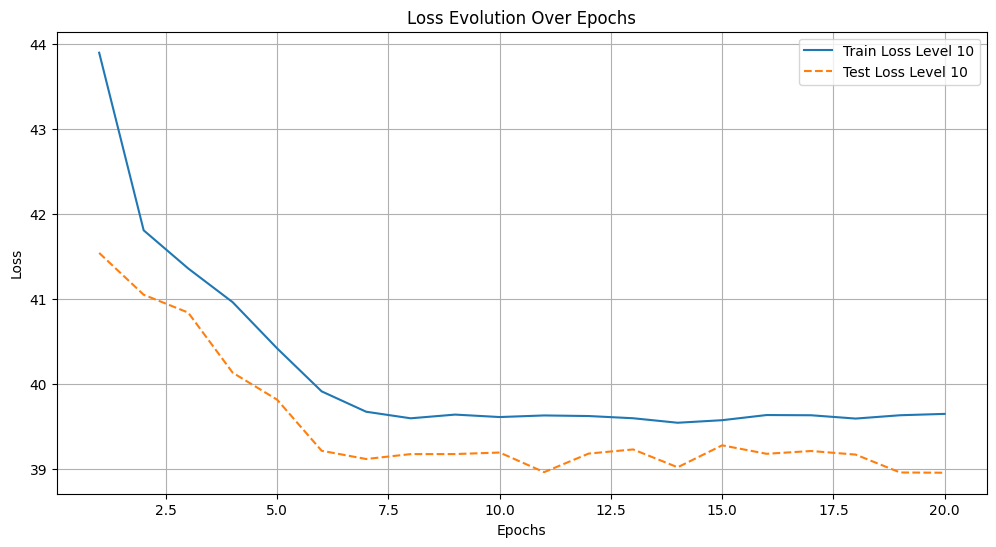

In [27]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    """
    Parse the .log file to extract training and testing losses.

    Args:
        log_file_path (str): Path to the .log file.

    Returns:
        dict: A dictionary containing train and test losses over epochs.
    """
    train_losses = []
    test_losses = []
    with open(log_file_path, 'r') as file:
        for line in file:
            # Match train loss lines
            train_match = re.match(r"\[Epoch \d+\] (.+)", line)
            if train_match:
                train_losses.append([float(x.strip()) for x in train_match.group(1).split(",")])

            # Match test loss lines
            test_match = re.match(r"\(test\)\s+(.+)", line)
            if test_match:
                test_losses.append([float(x.strip()) for x in test_match.group(1).split(",")])

    return {
        "train": np.array(train_losses),
        "test": np.array(test_losses),
    }

def plot_loss_evolution(loss_data, k_levels=None, save_path=None):
    """
    Plot the loss evolution over epochs for selected `k` levels during training and testing.

    Args:
        loss_data (dict): A dictionary containing train and test losses over epochs.
        k_levels (list, optional): List of `k` levels to plot. Defaults to all available levels.
        save_path (str, optional): Path to save the plot. If None, the plot is displayed.
    """
    train_losses = loss_data['train']
    test_losses = loss_data['test']

    if k_levels is None:
        k_levels = range(train_losses.shape[1])  # Default to all levels

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))
    for k in k_levels:
        if k < train_losses.shape[1]:  # Ensure k is valid
            plt.plot(epochs, train_losses[:, k], label=f"Train Loss Level {k}")
            if len(test_losses) > 0:
                plt.plot(epochs, test_losses[:, k], '--', label=f"Test Loss Level {k}")
        else:
            print(f"Warning: k level {k} is out of bounds and will be ignored.")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Evolution Over Epochs")
    plt.legend()
    plt.grid()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()

# Example usage
log_file_path = "log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)

# Specify the `k` levels you want to plot, or set to `None` to plot all levels
k_levels_to_plot = [10]  # Example: Plot only levels 0 and 2
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

In [ ]:
total_residual = reconstructed_da - ds_test
total_residual